## Pré-processamento dos dados

Nesta seção, serão utilizados os dados coletados por meio do _web scraping_ para a realização do pré-processamento das informações obtidas.

### Estrutura e natureza dos dados

Os dados possuem natureza majoritariamente textual e estão organizados em dois conjuntos principais: `vereador_pauta.csv` e `vereador_propostas_long.csv`.

Por se tratarem predominantemente de dados textuais, torna-se adequada a aplicação de técnicas de **Processamento de Linguagem Natural (NLP)** para possibilitar o tratamento, a padronização e a preparação dessas informações para etapas posteriores de análise.

No dataset `vereador_pauta.csv`, estão contidas as seguintes informações acerca dos vereadores:

- municipio
- slug
- nome
- partido
- telefone
- email
- foto
- url_perfil
- tem_bio
- n_propostas
- tipos_propostas
- propostas_json
- corpus_pautas

No dataset `vereador_propostas_long.csv`, estão contidas as seguintes informações:

- municipio
- vereador
- partido
- email
- telefone
- proposta_tipo
- proposta_numero
- proposta_ano
- proposta_ementa
- proposta_url

### Objetivos do pré-processamento

O pré-processamento tem como principais objetivos as seguintes ações:

- remoção de valores nulos e duplicados;
- normalização textual;
- remoção de caracteres especiais;
- transformação de texto para letras minúsculas;
- remoção de _stopwords_;
- tokenização;
- lematização ou stemming;
- preparação dos textos para vetorização e modelagem.

Essas etapas são fundamentais para melhorar a qualidade dos dados que serão o pilar principal do futuro sistema de recomendação.

### Estratégia de tratamento textual

Criarei a coluna `corpus_pautas`, que será utilizada como principal fonte textual para análise temática dos vereadores. Também terá a coluna `proposta_ementa`, que permitirá investigar padrões legislativos presentes nas propostas apresentadas.

Após o tratamento textual, os dados serão utilizados para modelagem de tópicos, treinamento do modelo de ML não supervisionado, etc.

Irei dividir o pré-processamento em etapas


#### 1) Carregamento dos datasets e primeiras análises


Primeiramente, importando as bibliotecas necessárias para a realização do pré-processamento da informação textual:


In [ ]:
# pandas para o armazenamento dos dados
# nltk e spacy para pegar ferramentas úteis para o processamento natural de linguagem
# matplotlib e seaborn para visualização gráfica
# wordcloud para visualização em nuvem
# re para ferramentas de limpeza
import pandas as pd
import nltk
import spacy
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re


Agora baixando os dados obtidos através do scraping com auxílio da biblioteca pandas em 2 datasets distintos:


In [2]:
df_pauta = pd.read_csv('data/vereador_pauta.csv')
df_propostas = pd.read_csv('data/vereador_propostas_long.csv')

Agora para a análise dos dados presentes em cada dataset.

##### **1.1) Analisando os dados do** `df_pauta`:


Lendo as 10 primeiras/últimas informações presentes no dataset:


In [3]:
df_pauta.head(10)

,municipio,slug,nome,partido,telefone,email,foto,url_perfil,tem_bio,n_propostas,tipos_propostas,propostas_json,corpus_pautas
0,Bayeux,bayeux,Cabo Rubem,PSB,NaN,caborubem@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,112,"EIMP, PDC, PDL, PLC, PLO, PR, REQ, VET","[{""tipo"": ""REQ"", ""numero"": 181, ""ano"": 2026, ""...",SOLICITA A CRIAÇÃO DO PROGRAMA “PRIMEIRO ESTÁG...
1,Bayeux,bayeux,Jays de Nita,PSB,NaN,jaysdenita@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,74,"ATOPR, CONV, DESPR, EDIT, EIMP, PLO, REQ","[{""tipo"": ""REQ"", ""numero"": 180, ""ano"": 2026, ""...",REQUER A AMPLIAÇÃO DA REDE DE APOIO E ASSISTÊN...
2,Bayeux,bayeux,Josauro Pereira,MDB,NaN,josauropereira@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,56,"EIMP, IND, PDL, PLO, REQ","[{""tipo"": ""REQ"", ""numero"": 179, ""ano"": 2026, ""...",REQUER AO PODER EXECUTIVO MUNICIPAL A CRIAÇÃO ...
3,Bayeux,bayeux,Wagner do Grau,PSD,NaN,wagnerdograu@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,41,"EIMP, EMD, INSLE, PLO, REQ, VET","[{""tipo"": ""REQ"", ""numero"": 169, ""ano"": 2026, ""...",REQUER O ENVIO DE EXPEDIENTE À EXMA. SRA. PREF...
4,Bayeux,bayeux,França,PT,NaN,franca@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,37,"EIMP, IND, PLO, REQ","[{""tipo"": ""REQ"", ""numero"": 183, ""ano"": 2026, ""...",REQUER A DESOBSTRUÇÃO E LIMPEZA DAS GALERIAS P...
5,Bayeux,bayeux,Pastora Anunciada,PSB,NaN,pastora.anunciada@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,32,"EIMP, PDL, PLO, REQ, REQAD","[{""tipo"": ""REQ"", ""numero"": 147, ""ano"": 2026, ""...","REQUER A SECRETARIA DE INFRAESTRUTURA, SERVIÇO..."
6,Bayeux,bayeux,Adriano do Táxi,PSB,NaN,adrianodotaxi@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,31,"EIMP, IND, PDL, PLO, PR, REQ","[{""tipo"": ""REQ"", ""numero"": 159, ""ano"": 2026, ""...",REQUER QUE SEJA ATRIBUIDO O CÓDIGO DE ENDEREÇA...
7,Bayeux,bayeux,Iara Caetano,REPUBLICANOS,NaN,iaracaetano@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,31,"EIMP, IND, PLO, REQ, RQAPR","[{""tipo"": ""REQ"", ""numero"": 66, ""ano"": 2026, ""e...",EMENTA: REQUER QUE SEJA REALIZADA A DESOBSTRUÇ...
8,Bayeux,bayeux,Berguinho Impacto Som,PV,NaN,berguinhodoimpactosom@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,26,"EIMP, PLO, REQ","[{""tipo"": ""REQ"", ""numero"": 173, ""ano"": 2026, ""...","REQUER, em caráter emergencial, o recapeamento..."
9,Bayeux,bayeux,Nildo da Casa Branca,MOBILIZA,NaN,nildodacasabranca@bayeux.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,NaN,False,22,"EIMP, ETA, PLO, PR, REQ","[{""tipo"": ""REQ"", ""numero"": 124, ""ano"": 2026, ""...",REQUER JUNTO A EMPRESA METROPOLITANA DE TRANS...


In [4]:
df_pauta.tail(10)

,municipio,slug,nome,partido,telefone,email,foto,url_perfil,tem_bio,n_propostas,tipos_propostas,propostas_json,corpus_pautas
87,Santa Rita,santa_rita,Anderson de Lima Liberato (Anderson Liberato),MOBILIZA,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,14,"EMD, PLO","[{""tipo"": ""EMD"", ""numero"": 172, ""ano"": 2025, ""...",EMENDA IMPOSITIVA/MODIFICATIVA/ADITIVA/SUBSTIT...
88,Santa Rita,santa_rita,David Santana dos Santos (David Santana),PARTIDO,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,14,"EMD, MOC, PLO","[{""tipo"": ""PLO"", ""numero"": 33, ""ano"": 2026, ""e...",Institui o Diagnóstico Municipal Permanente da...
89,Santa Rita,santa_rita,Marinaldo da Silva dos Santos Dore (Marinaldo),PP,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,13,"EMD, MOC, PLO","[{""tipo"": ""PLO"", ""numero"": 179, ""ano"": 2025, ""...",AUTORIZA O PODER EXECUTIVO A INSTITUIR O PROGR...
90,Santa Rita,santa_rita,Anésio Alves de Miranda Filho (Anésio Miranda),PP,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,6,"MOC, PLO","[{""tipo"": ""PLO"", ""numero"": 181, ""ano"": 2025, ""...",DISPÕE SOBRE DENOMINAÇÃO DE RUA E ADOTA OUTRA...
91,Santa Rita,santa_rita,Lemoell Ludovico Santana de Andrade (Lemoel Lu...,DC,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,6,"EMD, PLO","[{""tipo"": ""PLO"", ""numero"": 3, ""ano"": 2026, ""em...",PROJETO DE LEI ANTHONY CARLOS; Dispõe sobre a ...
92,Santa Rita,santa_rita,"Brunno Inocêncio da Nobrega Silva (Bruno, o fi...",PP,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,5,"EMD, MOC, PLO, REQ","[{""tipo"": ""EMD"", ""numero"": 183, ""ano"": 2025, ""...",EMENDA IMPOSITIVA/MODIFICATIVA/ADITIVA/SUBSTIT...
93,Santa Rita,santa_rita,Francisco Morais de Queiroga (Francisco Queiroga),PP,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,5,"EMD, MOC, PLO, PRE","[{""tipo"": ""PLO"", ""numero"": 2, ""ano"": 2026, ""em...",Dispõe sobre a Semana Municipal do Cicloturism...
94,Santa Rita,santa_rita,"Fagner Francelino dos Santos (Boquinha, filho ...",PDT,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,3,"MOC, PDL","[{""tipo"": ""MOC"", ""numero"": 6, ""ano"": 2025, ""em...",Moção de aplausos ao Sr. Josivandro Antônio do...
95,Santa Rita,santa_rita,Otávio Cassiano de Souza Silva (Otávio Bernard...,PDT,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,2,"EMD, MOC","[{""tipo"": ""EMD"", ""numero"": 121, ""ano"": 2025, ""...",EMENDA IMPOSITIVA AO PROJETO DE LEI 174/2025 (...
96,Santa Rita,santa_rita,Tiane de Berg,PP,NaN,NaN,https://www.santarita.pb.leg.br/site/wp-conten...,https://www.santarita.pb.leg.br/site/pt_veread...,False,0,NaN,[],NaN


Logo de cara, notam-se algumas informações importantes sobre os dados extraídos:

- url_perfil é uma coluna com diversos dados nulos (e que não agrega tanto na análise);
- O número de propostas está ordenado, com uma grande discrepância entre vereadores (um único com 100, enquanto a maioria apresenta entre 20 e 40), o que indica concentração da atividade legislativa em poucos parlamentares;
- A coluna tem_bio tem bastante valores falsos, o que pode ser um sinal de baixo engajamento/transparência do vereador;
- A coluna tem_bio tem bastante False, indicando ausência de biografias disponíveis sobre os vereadores;
- Há pouca disponibilidade de informações de contato, com o telefone ausente na maioria dos registros;
- Os partidos apresentam distribuição relativamente concentrada, com predominância do PSB;
- A coluna tipos_propostas revela uma diversidade de instrumentos legislativos, mas com forte presença de requerimentos (REQ) e projetos de lei ordinária (PLO).
- Os textos presentes em corpus_pautas sugerem uma atuação fortemente voltada para demandas locais, especialmente infraestrutura urbana, limpeza pública, drenagem, mobilidade e serviços municipais;

Agora para um resumo do dataset com .info():


In [5]:
df_pauta.info()

<class 'pandas.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   municipio        97 non-null     str  
 1   slug             97 non-null     str  
 2   nome             97 non-null     str  
 3   partido          61 non-null     str  
 4   telefone         23 non-null     str  
 5   email            44 non-null     str  
 6   foto             84 non-null     str  
 7   url_perfil       64 non-null     str  
 8   tem_bio          97 non-null     bool 
 9   n_propostas      97 non-null     int64
 10  tipos_propostas  94 non-null     str  
 11  propostas_json   97 non-null     str  
 12  corpus_pautas    95 non-null     str  
dtypes: bool(1), int64(1), str(11)
memory usage: 9.3 KB


Isso mostra que:

- Os tipos estão de acordo com a natureza dos dados (a maioria string, por se tratarem de dados essencialmente textuais);
- As colunas: telefone, email, url_perfil e foto, que contém informações pessoais acerca dos canddatos, estão bastante vazias, o que não afeta tanto o intuito do projeto uma vez que não acredito que alguém deva ser influenciado a escolher/realizar match com um caractere em razão de sua foto, email ou telefone;

Agora para o .describe():


In [6]:
df_pauta.describe(include='str')

,municipio,slug,nome,partido,telefone,email,foto,url_perfil,tipos_propostas,propostas_json,corpus_pautas
count,97,97,97,61,23,44,84,64,94,97,95
unique,5,5,97,19,22,18,84,64,45,95,95
top,João Pessoa,joao_pessoa,Cabo Rubem,PP,(83) 3218-6305,joaopessoa.pb.leg.br,http://sapl.bayeux.pb.leg.br/media/sapl/public...,https://www.camaracg.pb.gov.br/sargento-wellin...,PL,[],SOLICITA A CRIAÇÃO DO PROGRAMA “PRIMEIRO ESTÁG...
freq,28,28,1,12,2,27,1,1,28,3,1


O que essa célula mostra de informação nova:

- Reafirma que só são 5 municípios que estão tendo suas informações analisadas, com João Pessoa predominando (provavelmente por ser uma cidade maior);
- A coluna email tem apenas 18 valores únicos dentre os 44 totais (com o valor mais frequente "joaopessoa.pb.leg.br" aparecendo vite e sete vezes), o que indica inconsistência na coleta;
- O tipo de proposta PL ser o mais frequente (28 aparições) indica que parte da câmara opta por uma classificação simples das propostas utilizadas;

Agora descrevendo os valores numéricos:


In [7]:
df_pauta.describe()

,n_propostas
count,97.000000
mean,21.649485
std,22.090741
min,0.000000
25%,7.000000
50%,13.000000
75%,30.000000
max,112.000000


Isso deota uma observação inferida anteriormente ao utilizar do .head() e .tail(): há uma distribuição desigual do número de propostas dentre os candidatos, uma vez que a mediana se encontra no valor '13' e o valor máximo se encontra em '112'. Em suma, existe um pequeno grupo de vereadores que tem a produtividade acima da média, o que sugere a presença de possíveis outliers (casos extremos de produtividade), que merecem investigação para verificar se refletem diferenças reais de atuação parlamentar ou particularidades na forma de registro das proposições entre os municípios analisados.

Agora contabilizando a presença de valores nulos para a limpeza:


In [8]:
df_pauta.isnull().sum()

municipio           0
slug                0
nome                0
partido            36
telefone           74
email              53
foto               13
url_perfil         33
tem_bio             0
n_propostas         0
tipos_propostas     3
propostas_json      0
corpus_pautas       2
dtype: int64

Vendo se há duplicatas para limpá-las em caso positivo:


In [9]:
df_pauta.duplicated().sum()

np.int64(0)

##### **1.1.1) Limpeza de dados do** `df_pauta`:


Para a etapa de limpeza do `df_pauta`, devem ser considerados os devidos fatores:

- A presença de valores nulos em certas colunas;
- A utilidade de cada coluna na análise (seja pela qualidade da informação nela disposta ou pelo tipo de informação que ela guarda);
- Limpeza padrão do corpus;

Iniciando com a limpeza das colunas com valores nulos, estas que são: `partido`, `telefone`, `email`, `foto`e `url_perfil`. Dentre as 5 colunas, apenas partido contém informação realmente relevante para a análise. As informações de contato poderiam ser até um fator útil para a aplicação, entretanto, mais de 50% dos dados nelas presentes são nulos, o que torna sua disposição irrelevante. As colunas `foto`e `url_perfil` tem bastante dados nulos mas não chega a ser acima de 50%, além disso, são úteis na aplicação web.

**O que optei por fazer nesse caso?** Separar o `df_pauta` em 2 diferentes conjuntos de dados: dados para UI (foto, url_perfil, nome, etc) e dados para o NLP e sistema de recomendação (partido, tipo_propostas, etc). Para isso, juntarei informações relevantes do df_pauta com o `df_propostas` (que será avaliado no próximo tópico).

Antes de tudo, criando uma cópia do dataset para preservar as informações originais:


In [10]:
copia_df_pauta = df_pauta.copy()

Agora para a remoção das duas colunas com >50% de informações nulas:


In [11]:
cols_drop = ["telefone", "email"]
copia_df_pauta = copia_df_pauta.drop(columns=cols_drop)

Para as colunas com dados nulos que serão mantidas (foto e url_perfil) decidi fazer o seguinte:

- Na coluna fotos, colocar um avatar com a inicial dos nomes naqueles que não tem foto;
- Na coluna url_perfil, colocar "sem perfil" nos que não tem perfil;

Dessa forma, os dados nulos serão preenchidos com um "default" que não deixa as colunas "sujas".


In [12]:
copia_df_pauta['foto'] = copia_df_pauta['foto'].fillna("https://ui-avatars.com/api/?name=" + copia_df_pauta["nome"].str.replace(" ", "+"))

In [13]:
copia_df_pauta['url_perfil'] = copia_df_pauta['url_perfil'].fillna("sem_perfil")

Para a limpeza do corpus, deve-se antes analisar como está disposta a informação textual da coluna. Para isso, irei visualizar alguns dos textos e informações relevantes sobre eles:


In [14]:
print(f"Tamanho do corpus: {len(copia_df_pauta['corpus_pautas'])}")

Tamanho do corpus: 97


In [15]:
# primeiro dos textos
print(copia_df_pauta["corpus_pautas"].iloc[0])

SOLICITA A CRIAÇÃO DO PROGRAMA “PRIMEIRO ESTÁGIO MUNICIPAL”, DESTINADO À INSERÇÃO DE ESTUDANTES UNIVERSITÁRIOS E TÉCNICOS NO MERCADO DE TRABALHO NO MUNICÍPIO DEDE BAYEUX. | SOLICITA À SEMOB E À SECRETARIA MUNICIPAL DE INFRAESTRUTURA A REALIZAÇÃO DE ESTUDO TÉCNICO PARA RETIRADA OU RELOCAÇÃO DE QUEBRA-MOLAS NA RUA JOAQUIM NABUCO, NO BAIRRO IMACULADA. | SOLICITA À SECRETARIA MUNICIPAL DE INFRAESTRUTURA E AO DNIT A REALIZAÇÃO DE SERVIÇOS DE TAPA BURACOS E RECUPERAÇÃO ASFÁLTICA NA AVENIDA ENGENHEIRO DE CARVALHO E NAS IMEDIAÇÕES DO VIADUTO, NO SENTIDO JARDIM AEROPORTO. | SOLICITA À SECRETARIA MUNICIPAL DE INFRAESTRUTURA A REALIZAÇÃO DE SERVIÇOS DE CAPINAGEM, LIMPEZA E RETIRADA DE ENTULHOS NA RUA GENERAL MOURÃO FILHO, AVENIDA ENGENHEIRO EDGAR SEAGER E IMEDIAÇÕES DO COLÉGIO LUCIANO RIBEIRO DE MORAIS, NO BAIRRO ALTO DA BOA VISTA. | REQUER AO PODER EXECUTIVO MUNICIPAL A REALIZAÇÃO DE CAMPANHA PERMANENTE DE CONSCIENTIZAÇÃO, PREVENÇÃO E COMBATE AO ABUSO E À EXPLORAÇÃO SEXUAL DE CRIANÇAS E ADOLESCE

In [16]:
# snippet das 10 primeiras informações da coluna
copia_df_pauta['corpus_pautas'].head(10)

0    SOLICITA A CRIAÇÃO DO PROGRAMA “PRIMEIRO ESTÁG...
1    REQUER A AMPLIAÇÃO DA REDE DE APOIO E ASSISTÊN...
2    REQUER AO PODER EXECUTIVO MUNICIPAL A CRIAÇÃO ...
3    REQUER O ENVIO DE EXPEDIENTE À EXMA. SRA. PREF...
4    REQUER A DESOBSTRUÇÃO E LIMPEZA DAS GALERIAS P...
5    REQUER A SECRETARIA DE INFRAESTRUTURA, SERVIÇO...
6    REQUER QUE SEJA ATRIBUIDO O CÓDIGO DE ENDEREÇA...
7    EMENTA: REQUER QUE SEJA REALIZADA A DESOBSTRUÇ...
8    REQUER, em caráter emergencial, o recapeamento...
9    REQUER  JUNTO A EMPRESA METROPOLITANA DE TRANS...
Name: corpus_pautas, dtype: str

In [17]:
# snippet das 10 últimas informações da coluna
copia_df_pauta['corpus_pautas'].tail(10)

87    EMENDA IMPOSITIVA/MODIFICATIVA/ADITIVA/SUBSTIT...
88    Institui o Diagnóstico Municipal Permanente da...
89    AUTORIZA O PODER EXECUTIVO A INSTITUIR O PROGR...
90    DISPÕE SOBRE DENOMINAÇÃO DE RUA E ADOTA  OUTRA...
91    PROJETO DE LEI ANTHONY CARLOS; Dispõe sobre a ...
92    EMENDA IMPOSITIVA/MODIFICATIVA/ADITIVA/SUBSTIT...
93    Dispõe sobre a Semana Municipal do Cicloturism...
94    Moção de aplausos ao Sr. Josivandro Antônio do...
95    EMENDA IMPOSITIVA AO PROJETO DE LEI 174/2025 (...
96                                                  NaN
Name: corpus_pautas, dtype: str

In [18]:
# analisando o tamanho dos textos
copia_df_pauta['corpus_pautas'].str.len().describe()

count      95.000000
mean     2813.778947
std      1685.936713
min       176.000000
25%      1330.500000
50%      2466.000000
75%      4925.500000
max      5000.000000
Name: corpus_pautas, dtype: float64

In [19]:
# vendo os tamanhos dos 10 menores textos (próximos de 176 caracteres)
copia_df_pauta["corpus_pautas"].str.len().sort_values().head(10)

95    176.0
94    251.0
67    254.0
15    323.0
80    435.0
66    449.0
78    498.0
90    592.0
93    610.0
65    646.0
Name: corpus_pautas, dtype: float64

In [20]:
# mesma coisa com os 10 maiores textos: 
copia_df_pauta["corpus_pautas"].str.len().sort_values(ascending=False).head(10)

0     5000.0
1     5000.0
2     5000.0
3     5000.0
6     5000.0
18    5000.0
17    5000.0
20    5000.0
19    5000.0
21    5000.0
Name: corpus_pautas, dtype: float64

Características marcantes:

- Alguns dos textos estão inteiramente com letras em caixa alta e outros que misturam palavras inteiramente em caixa alta com palavras em caixa baixa. Como python é case sensitive, para evitar qualquer problema, é necessária a conversão de todo o texto para caracteres minúsculos. Desse modo, 'REQUER' e 'requer' serão tratados da mesma maneira;
- Os 10 maiores textos possuem exatamente o mesmo número de caracteres (5000), o que deve ser o limite de caracteres na seção de pautas;
- Os 10 menores textos tem tamanhos variados diferentemente dos maiores, nenhum absurdamente curto ou nulo;
- Como o tamanho dos textos pode ser um fator que denota engajamento do vereador e pode ser útil para o modelo, irei criar uma coluna que armazena esses valores;

Esses fatores todos serão considerados na função de limpeza do corpus.


In [21]:
# criando a coluna com tamanho do corpus antes da limpeza para fins comparativos
copia_df_pauta['tamanho_corpus_bruto']= copia_df_pauta['corpus_pautas'].str.len()

In [22]:
# função de limpeza do corpus
def limpar_corpus(txt):
    if pd.isna(txt):
        return txt
    txt = txt.replace("\xa0", " ") # &nbsp; para evitar quebras de linha e forçar multiplos espaços
    txt = re.sub(r"[^\w\s]", " ", txt) # pontuação
    txt = re.sub(r"\s+", " ", txt) # remove espaços duplos
    txt = txt.strip().lower() # deixa todos os textos minúsculos
    return txt

In [23]:
# aplicando a função de limpeza na coluna corpus
copia_df_pauta['corpus_pautas'].apply(limpar_corpus)

0     solicita a criação do programa primeiro estági...
1     requer a ampliação da rede de apoio e assistên...
2     requer ao poder executivo municipal a criação ...
3     requer o envio de expediente à exma sra prefei...
4     requer a desobstrução e limpeza das galerias p...
                            ...                        
92    emenda impositiva modificativa aditiva substit...
93    dispõe sobre a semana municipal do cicloturism...
94    moção de aplausos ao sr josivandro antônio dos...
95    emenda impositiva ao projeto de lei 174 2025 o...
96                                                  NaN
Name: corpus_pautas, Length: 97, dtype: str

In [24]:
# agora criando a coluna de tamanho do texto após a limpeza
copia_df_pauta['tamanho_corpus_limpo']= copia_df_pauta['corpus_pautas'].str.len()

In [25]:
# colocando as colunas de tamanho lado a lado pra ver se há alguma diferença gritante
diff = (copia_df_pauta["tamanho_corpus_bruto"] != copia_df_pauta["tamanho_corpus_limpo"])

total_diferentes = diff.sum()
print(f"{total_diferentes} linhas com tamanho diferente após limpeza")

if total_diferentes > 0:
    print(copia_df_pauta.loc[diff, ["nome", "tamanho_corpus_bruto", "tamanho_corpus_limpo"]])

2 linhas com tamanho diferente após limpeza
             nome  tamanho_corpus_bruto  tamanho_corpus_limpo
16  Jarbas Coelho                   NaN                   NaN
96  Tiane de Berg                   NaN                   NaN


O tamanho se manteve, provavelmente por que a limpeza feita agora não foi tão abrangente (pretendo aplicar mais técnicas de NLP após separar o dataset em 2) e as duas únicas colunas com "tamanho divergente", na verdade, são NaN, que são vereadores com propostas mas corpus vazio (ou sem proposta registrada). Buscando pra ver quais são:


In [26]:
nulos = copia_df_pauta[copia_df_pauta["corpus_pautas"].isna()]
print(nulos[["nome", "partido", "n_propostas"]])

             nome       partido  n_propostas
16  Jarbas Coelho  REPUBLICANOS            0
96  Tiane de Berg            PP            0


Sem propostas, logo, irei substituir o NaN por "sem propostas"


In [27]:
copia_df_pauta['corpus_pautas'] = copia_df_pauta['corpus_pautas'].fillna("sem_propostas")

Agora com a limpeza parcialmemte aplicada, vamos para a separação entre 2 datasets: o dataset com dados para UI do site e o dataset com as informações que serão utilizadas na NLP e no sistema de recomendação.


In [28]:
# dados de UI pro site
df_perfil = copia_df_pauta[["municipio", "nome", "partido", "foto", "url_perfil"]].copy()
# dados de NLP/ML
df_nlp = copia_df_pauta[["municipio", "nome", "partido", "tem_bio", "n_propostas", "tipos_propostas", "corpus_pautas", "tamanho_corpus_limpo"]].copy()

Esqueci de um detalhe: a coluna `partido` tem alguns valores nulos que não foram previamente tratados no df_pauta. Para isso, irei aplicar a mesma técnica que fiz em outras colunas que tinham valores nulos, que é preencher os valores faltantes com o trecho "sem_partido".


In [29]:
# mostrando que >30% dos valores estão vazios
df_perfil.isnull().sum()

municipio      0
nome           0
partido       36
foto           0
url_perfil     0
dtype: int64

In [30]:
# preenchendo os valores nulos
df_perfil['partido'] = df_perfil['partido'].fillna("sem_partido")

##### **1.2) Analisando os dados do** `df_propostas`:


Lendo as 10 primeiras/últimas informações presentes no dataset:


In [31]:
df_propostas.head(10)

,municipio,vereador,partido,email,telefone,proposta_tipo,proposta_numero,proposta_ano,proposta_ementa,proposta_url
0,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,181.0,2026.0,SOLICITA A CRIAÇÃO DO PROGRAMA “PRIMEIRO ESTÁG...,https://sapl.bayeux.pb.leg.br/materia/634
1,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,177.0,2026.0,SOLICITA À SEMOB E À SECRETARIA MUNICIPAL DE I...,https://sapl.bayeux.pb.leg.br/materia/627
2,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,176.0,2026.0,SOLICITA À SECRETARIA MUNICIPAL DE INFRAESTRUT...,https://sapl.bayeux.pb.leg.br/materia/626
3,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,175.0,2026.0,SOLICITA À SECRETARIA MUNICIPAL DE INFRAESTRUT...,https://sapl.bayeux.pb.leg.br/materia/625
4,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,168.0,2026.0,REQUER AO PODER EXECUTIVO MUNICIPAL A REALIZAÇ...,https://sapl.bayeux.pb.leg.br/materia/613
5,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,167.0,2026.0,REQUER À MESA DIRETORA DA CÂMARA MUNICIPAL DE ...,https://sapl.bayeux.pb.leg.br/materia/612
6,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,166.0,2026.0,REQUER A CONSTRUÇÃO DE UMA QUADRA POLIESPORTIV...,https://sapl.bayeux.pb.leg.br/materia/611
7,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,162.0,2026.0,REQUER AO PODER EXECUTIVO MUNICIPAL A REALIZAÇ...,https://sapl.bayeux.pb.leg.br/materia/604
8,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,158.0,2026.0,NaN,https://sapl.bayeux.pb.leg.br/materia/594
9,Bayeux,Cabo Rubem,PSB,caborubem@bayeux.pb.leg.br,NaN,REQ,157.0,2026.0,REQUER QUE SEJA CONCECIDO O PRESENTE VOTO DE A...,https://sapl.bayeux.pb.leg.br/materia/593


In [32]:
df_propostas.tail(10)

,municipio,vereador,partido,email,telefone,proposta_tipo,proposta_numero,proposta_ano,proposta_ementa,proposta_url
2093,Santa Rita,Francisco Morais de Queiroga (Francisco Queiroga),PP,NaN,NaN,EMD,120.0,2025.0,EMENDA IMPOSITIVA AO PROJETO DE LEI 174/2025 (...,https://sapl.santarita.pb.leg.br/materia/2290
2094,Santa Rita,Francisco Morais de Queiroga (Francisco Queiroga),PP,NaN,NaN,MOC,20.0,2025.0,MOÇÃO DE APLAUSOS A SECRETARIA DA ASSINTÊNCIA ...,https://sapl.santarita.pb.leg.br/materia/2061
2095,Santa Rita,Francisco Morais de Queiroga (Francisco Queiroga),PP,NaN,NaN,PRE,13.0,2025.0,Concede licença do mandato parlamentar ao Vere...,https://sapl.santarita.pb.leg.br/materia/2204
2096,Santa Rita,Francisco Morais de Queiroga (Francisco Queiroga),PP,NaN,NaN,PRE,12.0,2025.0,Concede licença do mandato parlamentar ao vere...,https://sapl.santarita.pb.leg.br/materia/2202
2097,Santa Rita,"Fagner Francelino dos Santos (Boquinha, filho ...",PDT,NaN,NaN,MOC,6.0,2025.0,Moção de aplausos ao Sr. Josivandro Antônio do...,https://sapl.santarita.pb.leg.br/materia/1221
2098,Santa Rita,"Fagner Francelino dos Santos (Boquinha, filho ...",PDT,NaN,NaN,PDL,4.0,2025.0,CONCEDE O TÍTULO DE CIDADÃO SANTARRITENSE AO S...,https://sapl.santarita.pb.leg.br/materia/1149
2099,Santa Rita,"Fagner Francelino dos Santos (Boquinha, filho ...",PDT,NaN,NaN,PDL,2.0,2025.0,Concede Titulo de Cidadão Santarritense ao Sen...,https://sapl.santarita.pb.leg.br/materia/1038
2100,Santa Rita,Otávio Cassiano de Souza Silva (Otávio Bernard...,PDT,NaN,NaN,EMD,121.0,2025.0,EMENDA IMPOSITIVA AO PROJETO DE LEI 174/2025 (...,https://sapl.santarita.pb.leg.br/materia/2291
2101,Santa Rita,Otávio Cassiano de Souza Silva (Otávio Bernard...,PDT,NaN,NaN,MOC,1.0,2025.0,Voto de Aplausos a Câmara dos Deputados Federa...,https://sapl.santarita.pb.leg.br/materia/1216
2102,Santa Rita,Tiane de Berg,PP,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df_propostas.columns

Index(['municipio', 'vereador', 'partido', 'email', 'telefone',
       'proposta_tipo', 'proposta_numero', 'proposta_ano', 'proposta_ementa',
       'proposta_url'],
      dtype='str')

Logo de cara, notam-se algumas informações importantes sobre os dados extraídos:

- A coluna `telefone` possui apenas dados nulos nas amostras visualizadas (e já foi previamente removida do df_pauta);
- Os partidos apresentam variação entre os municípios, com a presença de legendas como PSB, PP e PDT;
- A coluna `proposta_tipo` revela uma diversidade de instrumentos legislativos, com forte presença de requerimentos (REQ) no topo, mas também emendas impositivas (EMD), moções (MOC), projetos de resolução (PRE) e de decreto legislativo (PDL);
- Os textos presentes em `proposta_ementa` sugerem atuações com focos distintos: demandas voltadas para infraestrutura e serviços urbanos (Bayeux) e uma forte presença de matérias honoríficas, como títulos de cidadão e moções de aplausos, além de pautas orçamentárias (Santa Rita).

Agora para um resumo do dataset com .info():


In [34]:
df_propostas.info()

<class 'pandas.DataFrame'>
RangeIndex: 2103 entries, 0 to 2102
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   municipio        2103 non-null   str    
 1   vereador         2103 non-null   str    
 2   partido          1622 non-null   str    
 3   email            1176 non-null   str    
 4   telefone         552 non-null    str    
 5   proposta_tipo    2100 non-null   str    
 6   proposta_numero  2100 non-null   float64
 7   proposta_ano     2100 non-null   float64
 8   proposta_ementa  2009 non-null   str    
 9   proposta_url     2100 non-null   str    
dtypes: float64(2), str(8)
memory usage: 164.4 KB


Isso mostra que:

- Da mesma maneira que no df_pauta, as informações de contato possui >50% dos valores nulos (portanto serão removidas);
- Há uma menor quantidade de dados nulos fora email e telefone, apenas a coluna partido tem valores vazios (assim como no df_pauta);
- Os tipos de dado estão de acordo com sua natureza (str -> texto | int -> número);

Agora para o describe:


In [35]:
# describe para valores textuais
df_propostas.describe(include='str')

,municipio,vereador,partido,email,telefone,proposta_tipo,proposta_ementa,proposta_url
count,2103,2103,1622,1176,552,2100,2009,2100
unique,5,97,19,18,22,28,1784,1951
top,João Pessoa,Cabo Rubem,PSB,joaopessoa.pb.leg.br,(83) 3218-6326,PLO,EMENDA A LEI DE DIRETRIZES ORÇAMANTARIA 2026,https://falabr.cgu.gov.br/web/PB/Patos
freq,739,112,359,656,89,722,81,150


Informações obtidas por esse método:

- 97 vereadores assim como o número de linhas presente no df_pauta (ou seja: está de acordo);
- O vereador Cabo Rubem é o que possui o maior número de propostas;
- Há predominância de PLO (Projeto de Lei Ordinária), o que indica que a maioria das propostas vêm de temas do dia a dia e precisa apenas da maioria simples dos votos dos vereadores pra que seja aprovada;

(não vou aplicar o describe para valores numéricos por que se tratam de ano e número, valores que não requerem nenhuma análise muito grande)

Vendo qual ano possui mais propostas:


In [36]:
df_propostas['proposta_ano'].value_counts()

proposta_ano
2026.0    1328
2025.0     772
Name: count, dtype: int64

A maioria das propostas são recentes (2026), o que torna a análise e a criação do modelo ainda mais verossímil - reflete, realmente, a situação atual da câmara e também pode ser reflexo do ano eleitoral: por ser um ano de eleição, os candidatos decidem fazer mais propostas para mostrar proatividade e receberem votos. Agora para a verificação de dados nulos:


In [37]:
df_propostas.isnull().sum()

municipio             0
vereador              0
partido             481
email               927
telefone           1551
proposta_tipo         3
proposta_numero       3
proposta_ano          3
proposta_ementa      94
proposta_url          3
dtype: int64

In [38]:
df_propostas.duplicated().sum()

np.int64(4)

Há tanto dados nulos quanto duplicatas, o que exige limpeza.


##### **1.1.2) Limpeza de dados do** `df_propostas`:


Para a etapa de limpeza do `df_propostas`, devem ser considerados os seguintes fatores:

- A presença de valores nulos e duplicatas em certas colunas;
- A utilidade das colunas para a análise (nesse caso, ênfase na coluna `telefone` que, tanto no df_pauta quanto no df_propostas, tem >50% dos valores nulos);
- Limpeza padrão do corpus;

Iniciando com a limpeza das colunas com valores nulo, estas que são: partido, email, telefone, proposta_tipo, proposta_numero, proposta_ano, proposta_ementa, proposta_url - sendo telefone, email e partido as mais predominantes. Como a remoção das informações de contato foi realizada
no outro dataset, nada mais justo do que, também, remover nesse dataset;

Iniciando criando uma cópia do dataset para preservar as informações originais;


In [39]:
copia_df_propostas = df_propostas.copy()

Agora para a remoção da informação de contato que já foi previamente removida do dataset anterior:


In [40]:
# dropando as informações de contato
copia_df_propostas = copia_df_propostas.drop(columns=cols_drop)

Agora verificando quais outros valores que precisam de tratamento:


In [41]:
copia_df_propostas.isnull().sum()

municipio            0
vereador             0
partido            481
proposta_tipo        3
proposta_numero      3
proposta_ano         3
proposta_ementa     94
proposta_url         3
dtype: int64

Da mesma maneira que no `df_pauta`, a coluna partido tem alguns valores nulos que serão preenchidos da mesma maneira, ou seja, preenchendo com "sem_partido".


In [42]:
copia_df_propostas['partido'] = copia_df_propostas['partido'].fillna("sem_partido")

A mesma estratégia se mostra útil para as outras colunas que possuem valores nulos, uma vez que nehuma delas possui >50% dos valores nulos e nenhuma delas é passível de remoção, já que contém informações valiosas para a realização do match eleitoral. Aplicando em todas as colunas que tem valores nulos.


In [43]:
# primeiramente para as colunas textuais
colunas_texto = ['proposta_tipo', 'proposta_ementa', 'proposta_url']
for coluna in colunas_texto:
    copia_df_propostas[coluna] = copia_df_propostas[coluna].fillna(f"sem_{coluna}")


In [44]:
# numéricas separado
# o '-1' serve como sentinela numérica, isto é, o programa entende que é um valor ausente
copia_df_propostas["proposta_numero"] = copia_df_propostas["proposta_numero"].fillna(-1).astype("Int64")
copia_df_propostas["proposta_ano"] = copia_df_propostas["proposta_ano"].fillna(-1).astype("Int64")

Como a função de limpeza do corpus já foi feita, irei aplicá-la nas colunas que são interessantes para o match eleitoral, que são `proposta_ementa`e `proposta_tipo`


In [45]:
# aplicando a limpeza do corpus
copia_df_propostas["proposta_ementa"] = copia_df_propostas["proposta_ementa"].apply(limpar_corpus)
copia_df_propostas["proposta_tipo"] = copia_df_propostas["proposta_tipo"].str.strip().str.upper()

Visualizando os dados após as devidas técnicas de limpeza:


In [46]:
copia_df_propostas.head(10)

,municipio,vereador,partido,proposta_tipo,proposta_numero,proposta_ano,proposta_ementa,proposta_url
0,Bayeux,Cabo Rubem,PSB,REQ,181,2026,solicita a criação do programa primeiro estági...,https://sapl.bayeux.pb.leg.br/materia/634
1,Bayeux,Cabo Rubem,PSB,REQ,177,2026,solicita à semob e à secretaria municipal de i...,https://sapl.bayeux.pb.leg.br/materia/627
2,Bayeux,Cabo Rubem,PSB,REQ,176,2026,solicita à secretaria municipal de infraestrut...,https://sapl.bayeux.pb.leg.br/materia/626
3,Bayeux,Cabo Rubem,PSB,REQ,175,2026,solicita à secretaria municipal de infraestrut...,https://sapl.bayeux.pb.leg.br/materia/625
4,Bayeux,Cabo Rubem,PSB,REQ,168,2026,requer ao poder executivo municipal a realizaç...,https://sapl.bayeux.pb.leg.br/materia/613
5,Bayeux,Cabo Rubem,PSB,REQ,167,2026,requer à mesa diretora da câmara municipal de ...,https://sapl.bayeux.pb.leg.br/materia/612
6,Bayeux,Cabo Rubem,PSB,REQ,166,2026,requer a construção de uma quadra poliesportiv...,https://sapl.bayeux.pb.leg.br/materia/611
7,Bayeux,Cabo Rubem,PSB,REQ,162,2026,requer ao poder executivo municipal a realizaç...,https://sapl.bayeux.pb.leg.br/materia/604
8,Bayeux,Cabo Rubem,PSB,REQ,158,2026,sem_proposta_ementa,https://sapl.bayeux.pb.leg.br/materia/594
9,Bayeux,Cabo Rubem,PSB,REQ,157,2026,requer que seja concecido o presente voto de a...,https://sapl.bayeux.pb.leg.br/materia/593


Com os dados devidamente limpos, é possível unificar o df_nlp (feito com as informações necessárias para NLP do df_pauta) com as informações relevantes do df_propostas. Unificando num `df_nlp_final`:


In [47]:
# unificando num df_nlp_final
df_nlp_final = copia_df_propostas.merge(df_nlp, left_on=["municipio", "vereador"], right_on=["municipio", "nome"], how="left").drop(columns=["nome"])

In [48]:
# visualizando as colunas que estavam nela presentes:
df_nlp_final.columns

Index(['municipio', 'vereador', 'partido_x', 'proposta_tipo',
       'proposta_numero', 'proposta_ano', 'proposta_ementa', 'proposta_url',
       'partido_y', 'tem_bio', 'n_propostas', 'tipos_propostas',
       'corpus_pautas', 'tamanho_corpus_limpo'],
      dtype='str')

Ao observar com mais cautela, observei que a coluna corpus_pauta, na verdade, possui todas as ementas das propostas em um único índice. Ou seja, para um vereador "fulano" com 5 propostas 'a', 'b', 'c', 'd' e 'e', enquanto, para cada proposta, a coluna proposta_ementa tem uma delas, a coluna corpus_pauta possui todas elas juntas 5 vezes. Isso pode ser considerada informação redundante e ruidosa, porém, antes de dropar definitivamente, o corpus_pautas pode ser útil pra gerar um embedding único por vereador (ao invés de por proposta).

Para comparar vereadores entre si no autoencoder, esse texto agregado seria o insumo. A fim de solucionar essa lacuna em específico, decidi armazenar a corpus_pauta num df separado e dropar do df_nlp_final para não perder informação que pode ser importante para outras coisas mas, para a task específica de NLP, é redundante.

Destrinchando essa solução em código:


In [49]:
# salva o corpus por vereador separado antes de dropar
df_corpus_vereador = df_nlp_final[["municipio", "vereador", "corpus_pautas"]].drop_duplicates()

# aí dropa do df_nlp_final
df_nlp_final = df_nlp_final.drop(columns=["corpus_pautas"])

Após a limpeza e concatenação dos datasets a fim de deixar apenas as informações que serão devidamente utilizadas para o sistema de recomendação, podemos, finalmente, passar para o processamento natural de linguagem a fim de estruturar as informações que serão levadas em consideração no sistema de recomendação.


##### **2) NLP com os dados textuais**


Antes de qualquer coisa, preciso instalar e "setar" o ambiente para que seja realizado o processamento, este que consistirá nas seguintes etapas:

- Tokenização
- Lematização
- Remoção de Stopwords

As bibliotecas que serão utilizadas para a análise são, basicamente, `spacy` e `nltk`, uma vez que contém todos os tools necessários para que as etapas sejam sucessivamente efetivadas. Para uma melhor análise, irei utilizar de uma biblioteca de vocabulário da lingua portuguesa com vocabulário mais amplo e que possui vetores pré-treinados, que é a `pt_core_news_lg`. A fim de utilizá-lo, deve-se instalar as dependências necessárias


In [50]:
# instalando o modelo pt_news_core_lg para maior precisão
!python -m pip install -U spacy
!python -m spacy download pt_core_news_lg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 23.7 MB/s  0:00:30:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')


In [51]:
# instalando o modelo large em português
nlp = spacy.load("pt_core_news_lg")

Para verificar quais colunas demandarão das técnicas de NLP, deve-se analisar o tipo de conteúdo textual que cada uma armazena. Para isso, irei, novamente, utilizar da função `.head()` no `df_nlp_final`para ter um "snippet" dos dados:


In [52]:
df_nlp_final.head()

,municipio,vereador,partido_x,proposta_tipo,proposta_numero,proposta_ano,proposta_ementa,proposta_url,partido_y,tem_bio,n_propostas,tipos_propostas,tamanho_corpus_limpo
0,Bayeux,Cabo Rubem,PSB,REQ,181,2026,solicita a criação do programa primeiro estági...,https://sapl.bayeux.pb.leg.br/materia/634,PSB,False,112,"EIMP, PDC, PDL, PLC, PLO, PR, REQ, VET",5000.0
1,Bayeux,Cabo Rubem,PSB,REQ,177,2026,solicita à semob e à secretaria municipal de i...,https://sapl.bayeux.pb.leg.br/materia/627,PSB,False,112,"EIMP, PDC, PDL, PLC, PLO, PR, REQ, VET",5000.0
2,Bayeux,Cabo Rubem,PSB,REQ,176,2026,solicita à secretaria municipal de infraestrut...,https://sapl.bayeux.pb.leg.br/materia/626,PSB,False,112,"EIMP, PDC, PDL, PLC, PLO, PR, REQ, VET",5000.0
3,Bayeux,Cabo Rubem,PSB,REQ,175,2026,solicita à secretaria municipal de infraestrut...,https://sapl.bayeux.pb.leg.br/materia/625,PSB,False,112,"EIMP, PDC, PDL, PLC, PLO, PR, REQ, VET",5000.0
4,Bayeux,Cabo Rubem,PSB,REQ,168,2026,requer ao poder executivo municipal a realizaç...,https://sapl.bayeux.pb.leg.br/materia/613,PSB,False,112,"EIMP, PDC, PDL, PLC, PLO, PR, REQ, VET",5000.0


A única coluna que precisará das técnicas de NLP aplicadas é **proposta_ementa**, uma vez que é a única coluna textual que contém textos completos, com semâmtica e linguagem natural, não apenas:

- Nome de cidade/candidato;
- Sigla de partido/tipo de proposta;
- URLs;

como nas outras colunas textuais, que não passam de identificadores ou categorias sem semântica.

Com a identificação realizada, basta aplicar o pipeline de processamento natural de linguagem.


##### **2.1) Tokenização**


Para tokenizar a informação textual na coluna alvo (proposta_ementa), precisamos verificar como estão dispostas as informações (nesse caso, se há ruído, coisas do tipo). Testando com uma proposta dentre as linhas da coluna:


In [53]:
# testando efetividade da tokenização de uma pauta de um vereador
import random

tokens = [token.text for token in nlp(df_nlp_final['proposta_ementa'][random.randint(0, 2099)])]
print(tokens)

['institui', 'a', 'política', 'municipal', 'de', 'atração', 'e', 'acolhimento', 'de', 'nômades', 'digitais', 'campina', 'tech', 'nomad', 'no', 'âmbito', 'do', 'município', 'de', 'campina', 'grande', 'e', 'dá', 'outras', 'providências']


Após exaustivamente testar a função de tokenização em colunas aleatórias, notei que a divisão de tokens, em nenhum dos casos, trouxe caracteres que não são letras (como , : ! etc) e os caracteres já são todos minúsculos, o que indica uma tokenização sucessiva. Mas como testes soltos não bastam para confirmar a efetividade completa da tokenização, irei padronizar a informação que foi tokenizada com compreensão de lista:


In [54]:
# aplicando função de padronização que deixa tudo maiúsculo e só mantém letras
# mantive acentos para evitar ambiguidades nos significados
# ex.: a e à
df_nlp_final["proposta_ementa_tokenizada"] = df_nlp_final["proposta_ementa"].apply(lambda x: [token.text.lower() for token in nlp(x) if token.is_alpha])

In [55]:
# visualizando as 10 primeiras informações da nova coluna recém tokenizada
df_nlp_final['proposta_ementa_tokenizada'].head(10)

0    [solicita, a, criação, do, programa, primeiro,...
1    [solicita, à, semob, e, à, secretaria, municip...
2    [solicita, à, secretaria, municipal, de, infra...
3    [solicita, à, secretaria, municipal, de, infra...
4    [requer, ao, poder, executivo, municipal, a, r...
5    [requer, à, mesa, diretora, da, câmara, munici...
6    [requer, a, construção, de, uma, quadra, polie...
7    [requer, ao, poder, executivo, municipal, a, r...
8                                                   []
9    [requer, que, seja, concecido, o, presente, vo...
Name: proposta_ementa_tokenizada, dtype: object

In [56]:
# testando com uma coluna aleatória
print(df_nlp_final['proposta_ementa_tokenizada'][random.randint(0, 2099)])

['institui', 'o', 'programa', 'municipal', 'de', 'valorização', 'do', 'trabalhador', 'regido', 'pela', 'consolidação', 'das', 'leis', 'do', 'trabalho', 'clt', 'no', 'município', 'de', 'joão', 'pessoa', 'e', 'dá', 'outras', 'providências']


##### **2.2) Remoção de stop words**


Com a tokenização efetivamente realizada, deve-se, agora, remover as chamadas "stop words", que são palavras que não agregam significado (tipo artigos: 'a' 'o'). Para removê-las, devemos instalar uma base de dados de stop words em português da biblioteca NLTK e, a partir dessa base, realizar o processo.

Instalando a base de dados:


In [57]:
# baixando a base de dados
nltk.download('stopwords')
# acessa as stop words em português
pt_stopwords = stopwords.words('portuguese')
# visualizando as 10 primeiras
print(pt_stopwords[:10]) 
# vendo o tamanho do conjunto
print("Número de stop-words: ",len(pt_stopwords))


['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as']
Número de stop-words:  207


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/larissa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Aplicando a remoção de stop words em português na coluna já tokenizada:


In [58]:
def remover_stopwords(txt):
    # se já for lista (tokenizada)
    if isinstance(txt, list):
        return [t for t in txt if t not in pt_stopwords]
    # se for string normal
    if pd.isna(txt) or txt == "sem_proposta_ementa":
        return ""
    tokens = txt.split()
    return " ".join([t for t in tokens if t not in pt_stopwords])

df_nlp_final["ementa_sem_stopwords"] = df_nlp_final["proposta_ementa_tokenizada"].apply(remover_stopwords)

In [59]:
# visualizando como ficou após a remoção
df_nlp_final['ementa_sem_stopwords'].head(10)

0    [solicita, criação, programa, primeiro, estági...
1    [solicita, semob, secretaria, municipal, infra...
2    [solicita, secretaria, municipal, infraestrutu...
3    [solicita, secretaria, municipal, infraestrutu...
4    [requer, poder, executivo, municipal, realizaç...
5    [requer, mesa, diretora, câmara, municipal, ba...
6    [requer, construção, quadra, poliesportiva, es...
7    [requer, poder, executivo, municipal, realizaç...
8                                                   []
9    [requer, concecido, presente, voto, aplausos, ...
Name: ementa_sem_stopwords, dtype: object

##### **2.3) Lematização**


Para reduzir palavras a sua forma mais basal, a lematização é a abordagem mais adequada para este projeto, pois preserva o significado real das palavras ao reduzi-las à sua forma base canônica, essencial tanto pros embeddings semânticos quanto para a legibilidade das informações exibidas ao cidadão na plataforma. Em um domínio legislativo, onde termos como "requerimento", "pavimentação" e "infraestrutura" carregam significado político e técnico preciso, o stemming seria prejudicial por truncar essas palavras de forma agressiva e descontextualizada, o que atrapalharia na representação vetorial e, consequentemente, a qualidade do sistema de recomendação.

Aplicando, então, a lematização com ajuda do spacy:


In [62]:
pt_stopwords = set(pt_stopwords)  
pt_stopwords.update(["dede"])    

def lematizar(txt):
    if not isinstance(txt, list) and (pd.isna(txt) or txt == "sem_proposta_ementa"):
        return []
    texto = " ".join(txt) if isinstance(txt, list) else txt
    doc = nlp(texto)
    return [
        token.lemma_ for token in doc
        if len(token) > 2
        and token.lemma_.lower() not in pt_stopwords
        and not token.is_punct
        and token.is_alpha
    ]

df_nlp_final["ementa_lematizada"] = df_nlp_final["proposta_ementa"].apply(lematizar)

Visualizando os resultados na primeira coluna:


In [63]:
df_nlp_final["ementa_lematizada"].iloc[0]

['solicitar',
 'criação',
 'programa',
 'primeiro',
 'estágio',
 'municipal',
 'destinar',
 'inserção',
 'estudante',
 'universitário',
 'técnico',
 'mercado',
 'trabalho',
 'município',
 'Bayeux']

In [64]:
# vendo numa coluna aleatória
df_nlp_final["ementa_lematizada"].iloc[random.randint(0,2099)]

['requerer',
 'providência',
 'desocupação',
 'permissão',
 'ocupação',
 'ambulante',
 'área',
 'destinar',
 'praça',
 'taxi',
 'torno',
 'mercado',
 'público']

Com o texto, finalmente, processado devidamente, optei por utilizar de uma wordcloud pra ver as palavras predominantes nas ementas e ver, também, se tem alguma stop word que ainda prevalece ao longo da coluna. Visualizando no wordcloud:


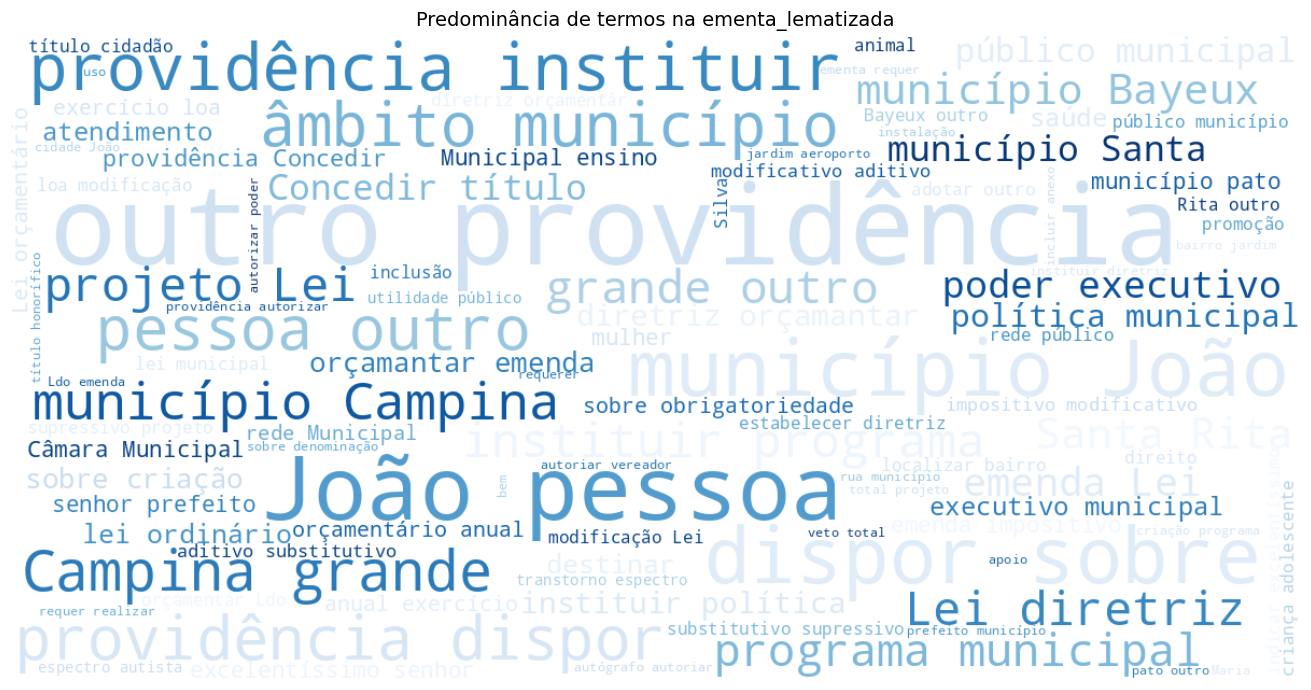

In [ ]:
# juntando todos os tokens em uma string
texto_completo = " ".join([token for lista in df_nlp_final["ementa_lematizada"].dropna() if isinstance(lista, list) for token in lista])

# gerando o wordcloud
wordcloud = WordCloud(width=1200, height=600, background_color="white", colormap="Blues", max_words=100).generate(texto_completo)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Predominância de termos na ementa_lematizada", fontsize=14)
plt.tight_layout()
plt.show()

Com base no wordcloud, observa-se uma forte predominância de termos de boilerplate legislativo, expressões como "providência", "outro" e "âmbito" que aparecem de forma padronizada ao final de praticamente toda proposição ("e dá outras providências", "no âmbito do município"), sem carregar valor semântico que possa ajudar na recomendação. Esses termos foram removidos das stopwords por não contribuírem para a clusterização por aparecerem com frequência em todas as propostas. Os demais termos dominantes, como "institui", "dispor", "programa" e "projeto", foram preservados por que sinalizam a intenção da proposta, sendo relevantes para a separação de clusters.


In [65]:
ruido = ["outro", "providência", "âmbito", "excelentíssimo", "senhor"]
pt_stopwords.update(ruido)
df_nlp_final["ementa_lematizada"] = df_nlp_final["ementa_lematizada"].apply(lematizar)


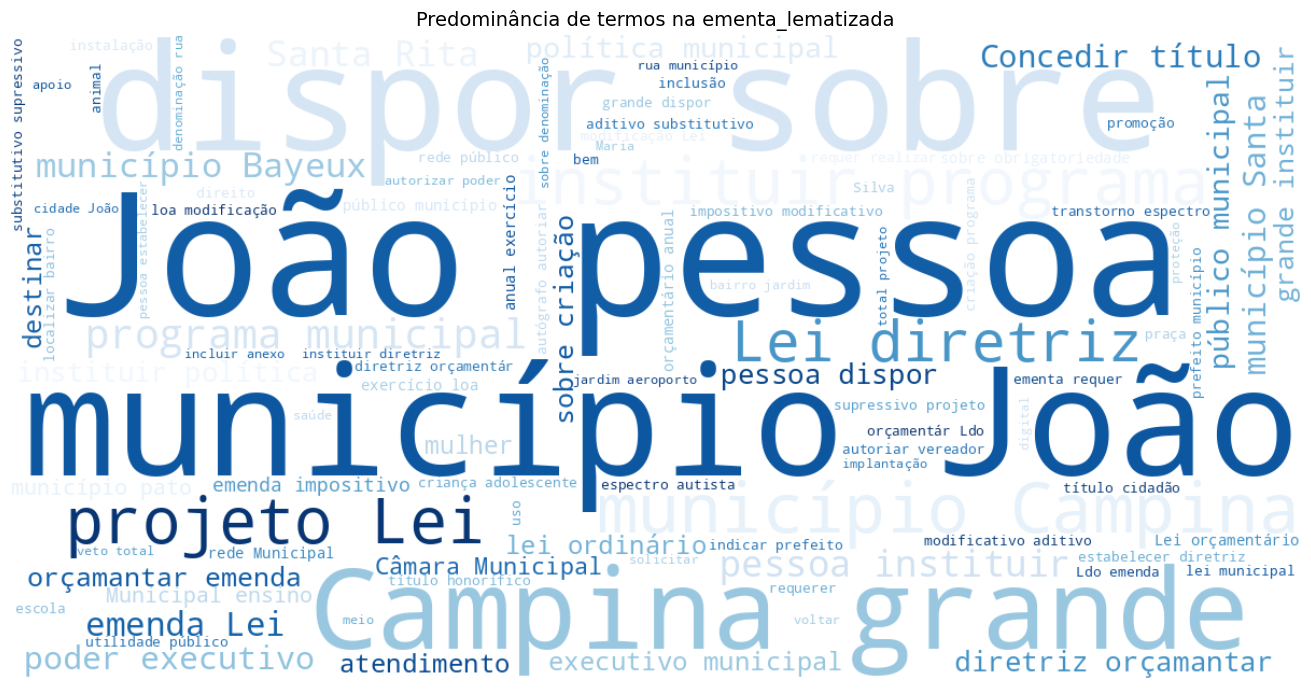

In [ ]:
# mostrando, novamente o wordcloud
texto_completo = " ".join([token for lista in df_nlp_final["ementa_lematizada"].dropna() if isinstance(lista, list) for token in lista])

wordcloud = WordCloud(width=1200, height=600, background_color="white", colormap="Blues", max_words=100).generate(texto_completo)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Predominância de termos na ementa_lematizada", fontsize=14)
plt.tight_layout()
plt.show()

In [67]:
import ast

In [68]:
# salvando datasets finais pre-processados como CSV
df_nlp_final.to_csv("df_nlp_final.csv", index=False)

df_nlp_final = pd.read_csv("df_nlp_final.csv")

df_nlp_final["ementa_lematizada"] = df_nlp_final["ementa_lematizada"].apply(ast.literal_eval)

## Conclusão do Pré-processamento e NLP

A partir dos dados brutos extraídos do SAPL dos municípios, foram realizadas as seguintes etapas:

**Pré-processamento**

- Remoção de colunas que não ajudariam tanto na análise (`telefone` e `email`) e separação entre dados de UI (`df_perfil`) e dados de NLP/ML (`df_nlp`);
- Tratamento de valores nulos com sentinels apropriados (`"sem_proposta_ementa"`, `"sem_perfil"`, `-1`);
- Merge entre `df_propostas` e `df_nlp`, resultando em `df_nlp_final` com ~2100 linhas, uma por proposta com contexto do vereador anexado;

**NLP**

- Limpeza textual com remoção de ruído HTML, pontuação e espaços irregulares;
- Remoção de stopwords em português via NLTK, com adição de termos de boilerplate legislativo sem valor semântico diferenciador;
- Lematização via SpaCy (`pt_core_news_sm`), reduzindo palavras à sua forma base canônica e preservando significado semântico;
- Validação via wordcloud, que confirmou predominância de termos legislativos e temáticos relevantes para a clusterização;

**Exportação**

- `df_nlp_final` exportado em `.csv` para consumo na próxima etapa, ao carregar, a coluna `ementa_lematizada` deve ser convertida de volta para lista via `ast.literal_eval`;
- `df_perfil` exportado em `.csv` para consumo pela camada de UI da aplicação web;

O dataset `df_nlp_final` está pronto para a próxima etapa: geração de embeddings via LLM API e aplicação do autoencoder para clusterização não-supervisionada das propostas.


#### **EXTRA**: Geração de resumos com LLM (Groq)

Para tornar as ementas acessíveis pro usuário, utilizei da api do 'groq' com o modelo `llama-3.1-8b-instant` para gerar um resumo em linguagem simples de cada proposta.


In [ ]:
# aplicando a api do groq em cada uma das propostas
from groq import Groq
import os
import time
from dotenv import load_dotenv

load_dotenv()
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

def gerar_resumo(ementa: str) -> str:
    if ementa == "sem_proposta_ementa":
        return "sem resumo disponível"
    try:
        time.sleep(1)
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            max_tokens=150,
            messages=[{"role": "user", "content": f"""Resuma em 1 frase curta e simples o que esta proposta legislativa pede, em linguagem acessível ao cidadão comum: {ementa}"""}]
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Erro: {e}")
        time.sleep(10)
        return gerar_resumo(ementa)

resumos = []
total = len(df_nlp_final)

for i, ementa in enumerate(df_nlp_final["proposta_ementa"]):
    resumos.append(gerar_resumo(ementa))
    if (i + 1) % 5 == 0:
        print(f"Progresso: {i + 1}/{total} ({((i+1)/total*100):.1f}%)")

df_nlp_final["resumo_proposta"] = resumos

Progresso: 5/2103 (0.2%)
Progresso: 10/2103 (0.5%)
Progresso: 15/2103 (0.7%)
Progresso: 20/2103 (1.0%)
Progresso: 25/2103 (1.2%)
Progresso: 30/2103 (1.4%)
Progresso: 35/2103 (1.7%)
Progresso: 40/2103 (1.9%)
Progresso: 45/2103 (2.1%)
Progresso: 50/2103 (2.4%)
Progresso: 55/2103 (2.6%)
Progresso: 60/2103 (2.9%)
Progresso: 65/2103 (3.1%)
Progresso: 70/2103 (3.3%)
Progresso: 75/2103 (3.6%)
Progresso: 80/2103 (3.8%)
Progresso: 85/2103 (4.0%)
Progresso: 90/2103 (4.3%)
Progresso: 95/2103 (4.5%)
Progresso: 100/2103 (4.8%)
Progresso: 105/2103 (5.0%)
Progresso: 110/2103 (5.2%)
Progresso: 115/2103 (5.5%)
Progresso: 120/2103 (5.7%)
Progresso: 125/2103 (5.9%)
Progresso: 130/2103 (6.2%)
Progresso: 135/2103 (6.4%)
Progresso: 140/2103 (6.7%)
Progresso: 145/2103 (6.9%)
Progresso: 150/2103 (7.1%)
Progresso: 155/2103 (7.4%)
Progresso: 160/2103 (7.6%)
Progresso: 165/2103 (7.8%)
Progresso: 170/2103 (8.1%)
Progresso: 175/2103 (8.3%)
Progresso: 180/2103 (8.6%)
Progresso: 185/2103 (8.8%)
Progresso: 190/2103 (

In [ ]:
# testando numa célula aleatória
df_nlp_final["resumo_proposta"].iloc[random.randint(0,2099)]

'Esse projeto de lei propõe mudar o nome do campo jaburuzão para severino maroja e do campo central para o marojão no distrito de bebelândia.'

In [110]:
# salvando datasets finais pós resumo
df_nlp_final.to_csv("df_nlp_final.csv", index=False)

df_nlp_final = pd.read_csv("df_nlp_final.csv")

df_nlp_final["ementa_lematizada"] = df_nlp_final["ementa_lematizada"].apply(ast.literal_eval)